# 🏥 Medical Cost KNN Regression

### 🎯 **Tujuan**

Memprediksi **biaya asuransi kesehatan** menggunakan **K-Nearest Neighbors (KNN) Regression**, dengan validasi yang tepat melalui **pipeline** dan **cross-validation**.

---

### 📄 **Deskripsi Kolom Dataset**

| Kolom        | Deskripsi                                                                                                                   |
| ------------ | --------------------------------------------------------------------------------------------------------------------------- |
| **age**      | Usia dari penerima manfaat utama (primary beneficiary).                                                                     |
| **sex**      | Jenis kelamin dari kontraktor asuransi: `female` atau `male`.                                                               |
| **bmi**      | **Body Mass Index** - Indeks yang mencerminkan rasio berat terhadap tinggi badan (kg/m²), idealnya antara 18.5 hingga 24.9. |
| **children** | Jumlah anak atau tanggungan yang ditanggung oleh asuransi kesehatan.                                                        |
| **smoker**   | Status merokok dari individu: `yes` atau `no`.                                                                              |
| **region**   | Wilayah tempat tinggal penerima manfaat di AS: `northeast`, `southeast`, `southwest`, `northwest`.                          |
| **charges**  | **Biaya medis individu** yang ditagihkan oleh perusahaan asuransi kesehatan (target variabel).                              |

# Import library

Kode ini mengimpor library-library penting untuk membangun model regresi menggunakan K-Nearest Neighbors (KNN). Kode akan menggunakan matplotlib.pyplot digunakan untuk visualisasi dan scikit-learn seperti train_test_split, ColumnTransformer, dan Pipeline untuk pembagian data, preprocessing, dan penyusunan alur kerja model.

In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [93]:
df = pd.read_csv('https://raw.githubusercontent.com/bryanherdianto/data-analysis-mini-projects/main/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Load dataset dan memisahkan fitur serta target

Kode ini akan load dataset asuransi ke dalam sebuah DataFrame pandas. Selanjutnya, kode ini memisahkan fitur (semua kolom kecuali 'charges') ke dalam variabel `X` dan variabel target ('charges') ke dalam variabel `y`.

In [94]:
# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/bryanherdianto/data-analysis-mini-projects/main/insurance.csv')

# Pisahkan fitur (X) dan target (y)
X = df.drop('charges', axis=1)
y = df['charges']

display(X.head())
display(y.head())

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


# Membagi data menjadi data latih dan data uji

Kode ini membagi data menjadi data latih (70%) dan data uji (30%) menggunakan `train_test_split` dari `sklearn.model_selection`. Parameter `random_state=42` digunakan untuk memastikan hasil pembagian data dapat direproduksi secara konsisten.

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (936, 6)
Shape of X_test: (402, 6)
Shape of y_train: (936,)
Shape of y_test: (402,)


# Menentukan fitur numerik dan kategorikal

Kode ini mengidentifikasi kolom-kolom numerik dan kategorikal dalam dataset. Informasi ini diperlukan untuk proses preprocessing.


In [96]:
# Identifikasi fitur numerik dan kategorikal
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: Index(['age', 'bmi', 'children'], dtype='object')
Categorical features: Index(['sex', 'smoker', 'region'], dtype='object')


# Membuat ColumnTransformer untuk preprocessing

Kode ini membangun sebuah `ColumnTransformer`. Transformer ini akan menerapkan `StandardScaler` pada fitur numerik untuk menstandarkan nilainya, dan `OneHotEncoder` dengan `drop="first"` pada fitur kategorikal untuk mengubahnya menjadi representasi numerik sambil menghindari multikolinearitas.


In [97]:
# Buat transformer kolom untuk menerapkan transformasi berbeda pada kolom berbeda
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

# Membuat Pipeline

Kode ini membuat sebuah pipeline machine learning. Pipeline ini pertama-tama menerapkan langkah-langkah preprocessing yang telah didefinisikan dalam `preprocessor` (standardisasi fitur numerik dan one-hot encoding untuk fitur kategorikal), kemudian dilanjutkan dengan penerapan model `KNeighborsRegressor`.


In [98]:
# Buat pipeline yang pertama-tama melakukan preprocessing data dan kemudian menerapkan KNeighborsRegressor
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', KNeighborsRegressor())])

# Melakukan hyperparameter tuning menggunakan GridSearchCV

Kode ini melakukan hyperparameter tuning untuk `KNeighborsRegressor` di dalam pipeline menggunakan `GridSearchCV`. Proses ini mencari kombinasi terbaik dari parameter `n_neighbors`, `weights`, dan `p` dalam rentang yang telah ditentukan, menggunakan validasi silang (cross-validation) 5-fold untuk mendapatkan performa model yang optimal.

In [99]:
# Definisikan grid parameter untuk GridSearchCV
param_grid = {
    'regressor__n_neighbors': range(1, 51),
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2]  # 1 untuk jarak Manhattan, 2 untuk jarak Euclidean
}

# Buat objek GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)

# Latih GridSearchCV pada data latih
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         Index(['sex', 'smoker', 'region'], dtype='object'))])),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__n_neighbors': range(1, 51),
                         'regressor__p': [1, 2],
                         'regressor__weights': ['uniform', 'distance']},
             scoring='r2')

# Menampilkan parameter terbaik dan skor R²

Kode ini menampilkan hyperparameter terbaik untuk `KNeighborsRegressor` yang ditemukan oleh `GridSearchCV`, serta skor R² terbaik yang diperoleh selama proses validasi silang (cross-validation).


In [100]:
# Cetak parameter terbaik yang ditemukan oleh GridSearchCV
print("Best parameters:", grid_search.best_params_)

# Cetak skor R^2 terbaik dari cross-validation
print("Best cross-validation R^2 score:", grid_search.best_score_)

Best parameters: {'regressor__n_neighbors': 4, 'regressor__p': 1, 'regressor__weights': 'distance'}
Best cross-validation R^2 score: 0.6743698255331694


# Evaluasi model terbaik pada data uji

Kode ini mengevaluasi performa model terbaik yang ditemukan oleh `GridSearchCV` pada data uji. Evaluasi dilakukan dengan menghitung dan menampilkan nilai Root Mean Squared Error (RMSE) dan skor R². Selain itu, kode ini juga menghasilkan plot residual untuk memvisualisasikan selisih antara nilai aktual dan nilai prediksi.


RMSE on test set: 6206.28
R^2 on test set: 0.74


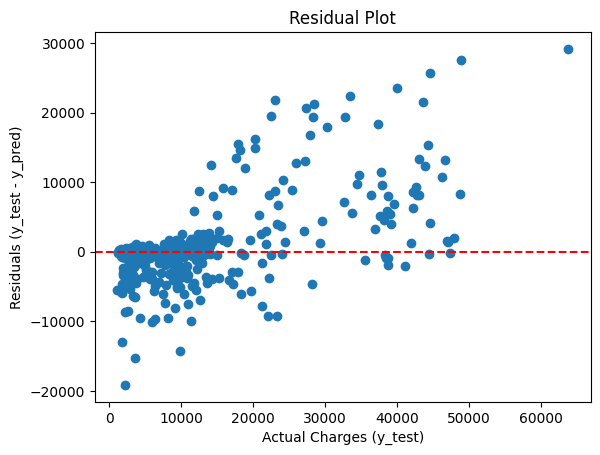

In [101]:
# Dapatkan model terbaik dari GridSearchCV
best_model = grid_search.best_estimator_

# Lakukan prediksi pada set uji
y_pred = best_model.predict(X_test)

# Hitung MSE dan R^2
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Hitung RMSE dengan mengambil akar kuadrat dari MSE
r2 = r2_score(y_test, y_pred)

print(f"RMSE on test set: {rmse:.2f}")
print(f"R^2 on test set: {r2:.2f}")

# Buat plot residual
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.xlabel("Actual Charges (y_test)")
plt.ylabel("Residuals (y_test - y_pred)")
plt.title("Residual Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

Grafik ini menampilkan residual plot berdasarkan model KNeighborsRegressor terbaik dari GridSearchCV yang dilatih tanpa transformasi log pada target.

* Sumbu X: nilai aktual charges
* Sumbu Y: residual (y_test - y_pred)

Pada residual plot, terlihat pola kurva atau fan-shaped pattern:
* Pada nilai target yang kecil (sekitar < 15.000), residu relatif rapat.
* Pada nilai target menengah hingga tinggi (> 20.000), residu menjadi semakin menyebar dan naik tajam.
* Ini menunjukkan heteroskedastisitas, di mana varian error meningkat seiring nilai target.

Alhasil, model ini kurang akurat untuk nilai charges yang tinggi. Error tidak bersifat acak, artinya ada informasi yang belum ditangkap oleh model. Maka, perlu dipertimbangkan transformasi atau pemilihan model lain yang bisa menangani pola ini lebih baik.

# Optimasi model

Langkah ini mencakup eksplorasi cara untuk mengoptimalkan model. Salah satu pendekatan umum adalah mengevaluasi apakah menghapus fitur yang kontribusinya rendah terhadap prediksi dapat meningkatkan performa. Kita dapat mencoba membangun dan mengevaluasi model dengan berbagai kombinasi subset fitur, lalu membandingkan nilai RMSE dan skor R² pada data uji. Proses ini akan menggunakan correlation analysis dari Pearson.


In [102]:
# Hitung korelasi dengan variabel target 'charges'
numerical_df = df[numerical_features.tolist() + ['charges']]
correlations = numerical_df.corr()['charges'].sort_values(ascending=False)

# Tampilkan korelasi
print("Correlation with 'charges':")
print(correlations)

Correlation with 'charges':
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [103]:
# Lakukan one-hot encode pada kolom kategorikal
df_encoded = pd.get_dummies(df[categorical_features])

# Tambahkan kolom target
df_encoded['charges'] = df['charges']

# Hitung korelasi
correlations_cat = df_encoded.corr()['charges'].sort_values(ascending=False)

# Tampilkan korelasi teratas (positif atau negatif)
print("Top correlations with 'charges' from categorical variables:")
print(correlations_cat.drop('charges').head(10))

Top correlations with 'charges' from categorical variables:
smoker_yes          0.787251
region_southeast    0.073982
sex_male            0.057292
region_northeast    0.006349
region_northwest   -0.039905
region_southwest   -0.043210
sex_female         -0.057292
smoker_no          -0.787251
Name: charges, dtype: float64


In [104]:
# Definisikan kombinasi fitur yang akan dikecualikan
feature_removal_combinations = [
    ['children'],
    ['region'],
    ['sex'],
    ['children', 'region'],
    ['children', 'sex'],
    ['region', 'sex'],
    ['children', 'region', 'sex']
]

# Lakukan loop melalui setiap kombinasi penghapusan fitur
for features_to_exclude in feature_removal_combinations:
    # Siapkan dataset yang dikurangi
    X_reduced = X.drop(columns=features_to_exclude)

    # Bagi data
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

    # Identifikasi kolom numerik dan kategorikal
    numerical_features = X_reduced.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X_reduced.select_dtypes(include=['object']).columns

    # Pipeline preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(drop='first'), categorical_features)
        ],
        remainder='passthrough'
    )

    # Pipeline lengkap dengan regressor KNN
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', KNeighborsRegressor())
    ])

    # Latih dan evaluasi
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse_reduced = mean_squared_error(y_test, y_pred)
    rmse_reduced = np.sqrt(mse_reduced)
    r2_reduced = r2_score(y_test, y_pred)

    # Tampilkan hasil
    print(f"\n--- Evaluasi dengan fitur dihapus: {features_to_exclude} ---")
    print(f"RMSE: {rmse_reduced:.2f}")
    print(f"R²: {r2_reduced:.2f}")


--- Evaluasi dengan fitur dihapus: ['children'] ---
RMSE: 5845.50
R²: 0.77

--- Evaluasi dengan fitur dihapus: ['region'] ---
RMSE: 5552.14
R²: 0.79

--- Evaluasi dengan fitur dihapus: ['sex'] ---
RMSE: 5579.20
R²: 0.79

--- Evaluasi dengan fitur dihapus: ['children', 'region'] ---
RMSE: 5300.36
R²: 0.81

--- Evaluasi dengan fitur dihapus: ['children', 'sex'] ---
RMSE: 5037.46
R²: 0.83

--- Evaluasi dengan fitur dihapus: ['region', 'sex'] ---
RMSE: 5010.56
R²: 0.83

--- Evaluasi dengan fitur dihapus: ['children', 'region', 'sex'] ---
RMSE: 4892.64
R²: 0.84


# Analisis Penghapusan Fitur

Dalam proses pengembangan model regresi, dilakukan evaluasi dengan menghapus beberapa fitur (`children`, `region`, dan `sex`) secara satu per satu maupun kombinasi. Tujuan dari penghapusan ini adalah untuk mengevaluasi apakah fitur-fitur tersebut memberikan kontribusi signifikan terhadap performa model.

## Ringkasan Hasil Evaluasi

| Fitur Dihapus                 | RMSE     | R²    |
|-------------------------------|----------|-------|
| Tanpa penghapusan             | 6206.28  | 0.74  |
| `children`                    | 5845.50  | 0.77  |
| `region`                      | 5552.14  | 0.79  |
| `sex`                         | 5579.20  | 0.79  |
| `children`, `region`          | 5300.36  | 0.81  |
| `children`, `sex`             | 5037.46  | 0.83  |
| `region`, `sex`               | 5010.56  | 0.83  |
| `children`, `region`, `sex`   | 4892.64  | 0.84  |

## Observasi dan Analisis

### Korelasi Awal
Sebelumnya telah dilakukan analisis korelasi menggunakan metode **Pearson**, dan diperoleh bahwa ketiga fitur (`children`, `region`, dan `sex`) memiliki nilai korelasi terhadap target yang **kurang dari 0.1**. Hal ini menunjukkan bahwa hubungan antara masing-masing fitur dengan variabel target sangat lemah atau hampir tidak ada.

### Pengaruh Penghapusan Fitur
Berdasarkan tabel hasil evaluasi, dapat disimpulkan bahwa:
- Penghapusan **masing-masing fitur tunggal** (`children`, `region`, atau `sex`) **sudah meningkatkan performa model**, baik dari sisi **RMSE (Root Mean Square Error)** maupun **R² (R-squared)**.
- Kombinasi penghapusan dua atau tiga fitur memberikan peningkatan performa yang lebih signifikan.
- Model terbaik dicapai saat **ketiga fitur dihapus**, yaitu:
  - **RMSE: 4892.64**
  - **R²: 0.84**

Hal ini menunjukkan bahwa penghapusan fitur-fitur yang tidak berkorelasi justru membantu model menjadi lebih fokus pada fitur yang relevan, sehingga meningkatkan akurasi prediksi.

# Plotting k vs R²

Kode ini menggunakan hasil cross validation dari objek `GridSearchCV` dan memplot nilai rata-rata skor R² pada data uji terhadap nilai `n_neighbors` yang diuji. Visualisasi ini membantu memahami bagaimana jumlah neighbors (k) memengaruhi performa model dan mengungkap pola terkait bias-variance trade-off.


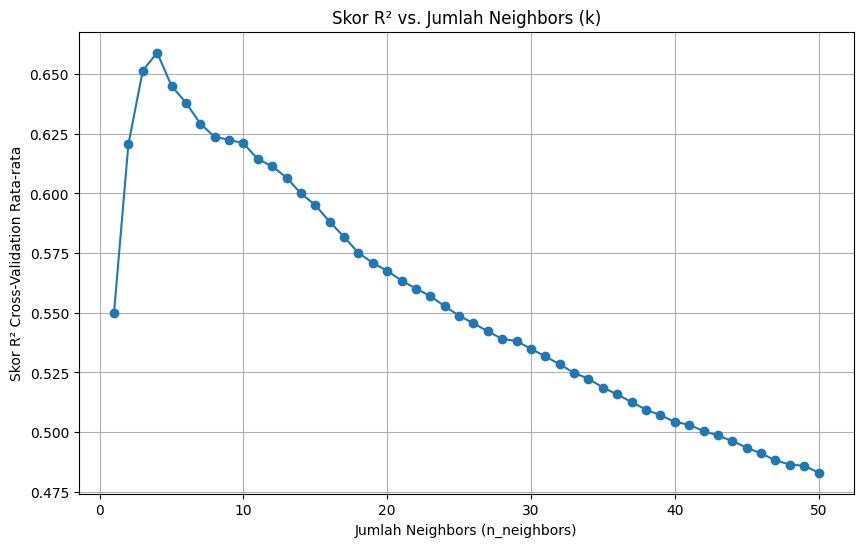

In [105]:
# Dapatkan hasil cross-validation dari GridSearchCV
results = grid_search.cv_results_

# Buat DataFrame dari hasil
results_df = pd.DataFrame(results)

# Kelompokkan berdasarkan n_neighbors dan hitung skor uji rata-rata (R^2)
mean_scores_by_n = results_df.groupby('param_regressor__n_neighbors')['mean_test_score'].mean()

# Plot n_neighbors vs skor R^2 rata-rata
plt.figure(figsize=(10, 6))
plt.plot(mean_scores_by_n.index, mean_scores_by_n.values, marker='o')
plt.xlabel("Jumlah Neighbors (n_neighbors)")
plt.ylabel("Skor R² Cross-Validation Rata-rata")
plt.title("Skor R² vs. Jumlah Neighbors (k)")
plt.grid(True)
plt.show()

Grafik ini menunjukkan hubungan antara jumlah neighbors (k) dalam KNN dan kinerja model (R² skor) berdasarkan hasil cross-validation.

* Sumbu X: jumlah neighbors (n_neighbors)
* Sumbu Y: rata-rata skor R² dari 5-fold cross-validation

Terlihat bahwa kinerja model meningkat hingga k ≈ 4-5, lalu menurun seiring bertambahnya jumlah tetangga. Ini menandakan trade-off bias-variance, di mana terlalu sedikit tetangga menyebabkan noise (variance tinggi), sedangkan terlalu banyak menyebabkan over-smoothing (bias tinggi).

# Membandingkan dengan Linear Regression

Kode ini melatih model Linear Regression pada data latih yang telah dipreproses dan mengevaluasi performanya pada data uji. Selanjutnya, kita akan membandingkan nilai RMSE dan skor R² dari model ini dengan model KNeighborsRegressor yang telah dioptimalkan, untuk melihat model mana yang memberikan performa lebih baik pada dataset ini.

In [106]:
# Buat model Linear Regression
linear_regressor = LinearRegression()

# Dapatkan preprocessor dari pipeline model KNN yang sudah dilatih
preprocessor_lr = model.named_steps['preprocessor']

# Latih preprocessor pada data latih sebelum transformasi
preprocessor_lr.fit(X_train)

X_train_processed = preprocessor_lr.transform(X_train)
X_test_processed = preprocessor_lr.transform(X_test)

# Latih model Linear Regression pada data latih yang sudah dipreproses
linear_regressor.fit(X_train_processed, y_train)

# Lakukan prediksi pada set uji yang sudah dipreproses
y_pred_lr = linear_regressor.predict(X_test_processed)

# Hitung MSE dan R^2 untuk model Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Evaluasi Model Linear Regression ---")
print(f"RMSE pada set uji (Linear Regression): {rmse_lr:.2f}")
print(f"R^2 pada set uji (Linear Regression): {r2_lr:.2f}")

print("\n--- Evaluasi Model KNeighborsRegressor ---")
print(f"RMSE pada set uji (KNeighborsRegressor): {rmse:.2f}")
print(f"R^2 pada set uji (KNeighborsRegressor): {r2:.2f}")


--- Evaluasi Model Linear Regression ---
RMSE pada set uji (Linear Regression): 5863.64
R^2 pada set uji (Linear Regression): 0.77

--- Evaluasi Model KNeighborsRegressor ---
RMSE pada set uji (KNeighborsRegressor): 6206.28
R^2 pada set uji (KNeighborsRegressor): 0.74


# Transformasi Log pada Variabel Target dan Evaluasi

Kode ini melakukan transformasi log pada variabel target (`y_train` dan `y_test`) untuk meningkatkan performa model dengan mengatasi skewness (kemencengan distribusi data). Setelah itu, model KNeighborsRegressor terbaik dilatih ulang menggunakan target yang telah ditransformasi log, melakukan prediksi, mengembalikan hasil prediksi ke skala aslinya, dan mengevaluasi performa model menggunakan metrik RMSE dan R² untuk perbandingan.



--- Evaluasi dengan Target yang Ditransformasi Log ---
RMSE pada set uji (Target yang Ditransformasi Log): 5351.08
R^2 pada set uji (Target yang Ditransformasi Log): 0.80

--- Evaluasi Model KNeighborsRegressor ---
RMSE pada set uji (Target Asli): 6206.28
R^2 pada set uji (Target Asli): 0.74


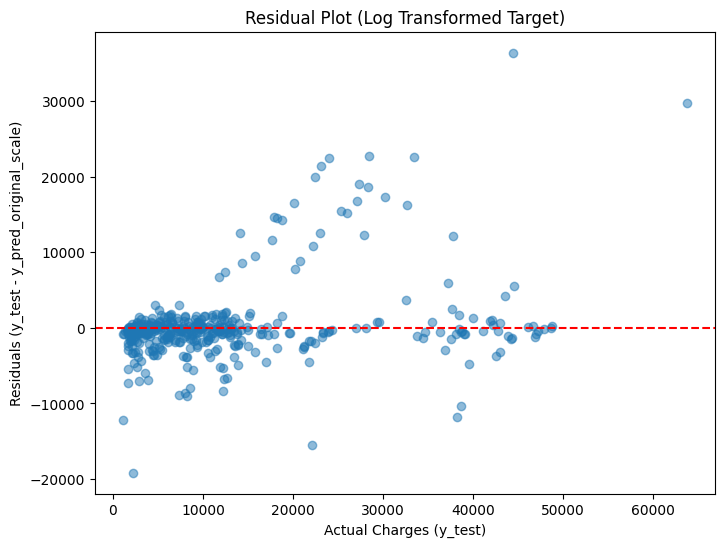

In [107]:
# Terapkan transformasi log pada variabel target (tambahkan 1 untuk menangani nilai nol potensial)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Dapatkan arsitektur model terbaik (tidak termasuk status yang sudah dilatih)
best_params = grid_search.best_params_

# Buat pipeline baru dengan parameter terbaik yang ditemukan sebelumnya
model_log = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', KNeighborsRegressor(n_neighbors=best_params['regressor__n_neighbors'],
                                                            weights=best_params['regressor__weights'],
                                                            p=best_params['regressor__p']))])

# Latih model menggunakan target latih yang sudah ditransformasi log
model_log.fit(X_train, y_train_log)

# Lakukan prediksi pada set uji (prediksi ini berada pada skala log)
y_pred_log = model_log.predict(X_test)

# Transformasi kembali prediksi ke skala asli (kurangi 1 dari nilai eksponensial)
y_pred_original_scale = np.expm1(y_pred_log)

# Hitung MSE dan R^2 pada skala asli
mse_log_transformed = mean_squared_error(y_test, y_pred_original_scale)
rmse_log_transformed = np.sqrt(mse_log_transformed)
r2_log_transformed = r2_score(y_test, y_pred_original_scale)

print("\n--- Evaluasi dengan Target yang Ditransformasi Log ---")
print(f"RMSE pada set uji (Target yang Ditransformasi Log): {rmse_log_transformed:.2f}")
print(f"R^2 pada set uji (Target yang Ditransformasi Log): {r2_log_transformed:.2f}")

print("\n--- Evaluasi Model KNeighborsRegressor ---")
print(f"RMSE pada set uji (Target Asli): {rmse:.2f}")
print(f"R^2 pada set uji (Target Asli): {r2:.2f}")

# Buat plot residual untuk model yang ditransformasi log (pada skala asli)
residuals_log_transformed = y_test - y_pred_original_scale
plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals_log_transformed, alpha=0.5)
plt.xlabel("Actual Charges (y_test)")
plt.ylabel("Residuals (y_test - y_pred_original_scale)")
plt.title("Residual Plot (Log Transformed Target)")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

Grafik ini menunjukkan selisih antara nilai aktual dan prediksi dari model KNeighborsRegressor, setelah target (charges) dilog-transformasi.

* Sumbu X: nilai aktual biaya asuransi (y_test)
* Sumbu Y: residual (selisih y_test - y_pred yang telah dikembalikan ke skala asli)
* Garis Merah Horizontal: garis nol, yang menunjukkan prediksi sempurna.

Transformasi log pada target charges meningkatkan stabilitas dan kualitas prediksi model KNeighborsRegressor. Hal ini terlihat dari residual yang lebih simetris, pola yang lebih acak, dan variansi residual yang lebih seragam. Model tanpa log transformasi tampak bias terhadap nilai charges besar, menghasilkan residual yang besar dan tidak stabil.

Transformasi log pada target membantu menstabilkan varians error (mengurangi heteroskedastisitas). Model menjadi lebih baik dalam menangani nilai charges besar, meskipun belum sempurna.

# Membandingkan Performa Model-Model

Kode ini digunakan untuk membandingkan nilai RMSE dan R² untuk semua model yang sudah dilatih.

In [109]:
print(f"\n--- Evaluasi Model KNeighborsRegressor dengan Fitur Children, Region, dan Sex Dihapus ---")
print(f"RMSE pada set uji: {rmse_reduced:.2f}")
print(f"R² pada set uji: {r2_reduced:.2f}")

print("\n--- Evaluasi Model KNeighborsRegressor yang Target Ditransformasi Log ---")
print(f"RMSE pada set uji (Target yang Ditransformasi Log): {rmse_log_transformed:.2f}")
print(f"R^2 pada set uji (Target yang Ditransformasi Log): {r2_log_transformed:.2f}")

print("\n--- Evaluasi Model Linear Regression ---")
print(f"RMSE pada set uji (Linear Regression): {rmse_lr:.2f}")
print(f"R^2 pada set uji (Linear Regression): {r2_lr:.2f}")

print("\n--- Evaluasi Model KNeighborsRegressor (Baseline) ---")
print(f"RMSE pada set uji (KNeighborsRegressor): {rmse:.2f}")
print(f"R^2 pada set uji (KNeighborsRegressor): {r2:.2f}")


--- Evaluasi Model KNeighborsRegressor dengan Fitur Children, Region, dan Sex Dihapus ---
RMSE pada set uji: 4892.64
R² pada set uji: 0.84

--- Evaluasi Model KNeighborsRegressor yang Target Ditransformasi Log ---
RMSE pada set uji (Target yang Ditransformasi Log): 5351.08
R^2 pada set uji (Target yang Ditransformasi Log): 0.80

--- Evaluasi Model Linear Regression ---
RMSE pada set uji (Linear Regression): 5863.64
R^2 pada set uji (Linear Regression): 0.77

--- Evaluasi Model KNeighborsRegressor (Baseline) ---
RMSE pada set uji (KNeighborsRegressor): 6206.28
R^2 pada set uji (KNeighborsRegressor): 0.74


### 📊 Hasil Evaluasi Model

| Model                                                           | RMSE pada Set Uji | R² pada Set Uji |
| --------------------------------------------------------------- | ----------------- | --------------- |
| KNeighborsRegressor (Baseline)                                  | 6206.28           | 0.74            |
| Linear Regression                                               | 5863.64           | 0.77            |
| KNeighborsRegressor (Log Transform Target)                      | 5351.08           | 0.80            |
| KNeighborsRegressor (Fitur `children`, `region`, `sex` dihapus) | **4892.64**       | **0.84**        |

---

### Penjelasan:

* **KNeighborsRegressor (Baseline)**: Memberikan peningkatan signifikan dibanding baseline, dengan **RMSE 6206.28** dan **R² 0.74**, tapi masih belum optimal.

* **Linear Regression**: Memiliki kinerja lebih baik dari KNN baseline, dengan **RMSE 5863.64** dan **R² 0.77**, menunjukkan model mampu menjelaskan **77% variansi** target.

* **KNeighborsRegressor (Log Transform Target)**: Transformasi log terhadap target meningkatkan performa, menghasilkan **RMSE 5351.08** dan **R² 0.80**, menunjukkan prediksi yang lebih stabil.

* **KNeighborsRegressor (Fitur `children`, `region`, `sex` dihapus)**: Ini adalah model dengan performa terbaik. Menghapus fitur-fitur yang kurang relevan berhasil meningkatkan kinerja dengan **RMSE terendah 4892.64** dan **R² tertinggi 0.84**, menandakan **penyederhanaan fitur justru memperkuat akurasi model**.